# M3 EPS Analysis

This notebook re-analyzes M3 using the paper's preferred throughput-style metric, `EPS` (embeddings per second),
instead of only `enum_time`.

The design follows the argument in `3639315.pdf`: rankings based on limited outputs or single time views may be biased,
while `EPS` offers a more stable picture of algorithm throughput.

## Setup

We recompute `eps_metric = embedding_count / total_time` for consistency with the paper's definition and
compare it with the stored `eps` column before using it in downstream analyses.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import analysis.m1_m3_analysis_lib as lib

lib.setup_notebook_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
FIG_DIR = ROOT / "analysis" / "figures"
PROCESSED_DIR = ROOT / "analysis" / "processed"

In [2]:
m3 = pd.read_parquet(PROCESSED_DIR / "m3_all.parquet")
m3["status_group"] = pd.Categorical(lib.normalize_status(m3["status"]), categories=["OK", "TIMEOUT", "CRASH"])
m3_ok = pd.read_parquet(PROCESSED_DIR / "m3_ok.parquet")
m3_eps_ok = lib.ok_eps_only(m3)

print("M3 shape:", m3.shape)
print("M3 OK shape:", m3_ok.shape)
print("M3 EPS-OK shape:", m3_eps_ok.shape)

M3 shape: (3292604, 24)
M3 OK shape: (1128422, 24)
M3 EPS-OK shape: (2326849, 25)


## EPS Sanity Check

Before relying on EPS, we verify that the stored `eps` field is effectively the same as `embedding_count / total_time`.

In [3]:
eps_check = pd.DataFrame(
    {
        "stored_eps_nonnull_rate": [m3_eps_ok["eps"].notna().mean()],
        "total_time_formula_match_rate": [
            np.isclose(
                m3_eps_ok["eps"],
                m3_eps_ok["embedding_count"] / m3_eps_ok["total_time"],
                rtol=1e-4,
                atol=1e-6,
            ).mean()
        ],
        "enum_time_formula_match_rate": [
            np.isclose(
                m3_eps_ok["eps"],
                m3_eps_ok["embedding_count"] / m3_eps_ok["enum_time"].replace(0, np.nan),
                rtol=1e-4,
                atol=1e-6,
            ).mean()
        ],
    }
)
eps_check

,stored_eps_nonnull_rate,total_time_formula_match_rate,enum_time_formula_match_rate
0,1.0,0.998161,0.008454


## Part 1: EPS Distribution and Reliability

We first inspect EPS distributions by engine and combine throughput with failure rate to understand the practical frontier.

In [4]:
eps_frontier = lib.eps_reliability_frontier(m3, m3_eps_ok)
eps_frontier

,engine,failure_rate,crash_rate,timeout_rate,median_eps,p90_eps,query_count
0,EXPLORE,0.109215,0.000000,0.109215,79999.996200,7.686006e+07,419054.0
1,LFTJ,0.118190,0.000000,0.118190,79999.996200,2.022743e+07,414808.0
2,QSI,0.119603,0.000000,0.119603,73204.820228,2.688000e+07,414113.0
3,KSS,0.128055,0.000000,0.128055,47999.997720,4.426147e+07,410046.0
4,GQL,0.178828,0.000000,0.178828,39999.998100,8.800000e+06,386156.0
5,RM,0.399037,0.295028,0.104009,198743.659982,2.183868e+08,282672.0
6,VF3,1.000000,0.994432,0.005568,NaN,NaN,NaN


/home/ranmaoyin/graph_query/Fastest-par/analysis/m1_m3_analysis_lib.py:957: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=sample, x="engine", y="log_eps", order=ENGINES, palette=PLOT_COLORS, cut=0)


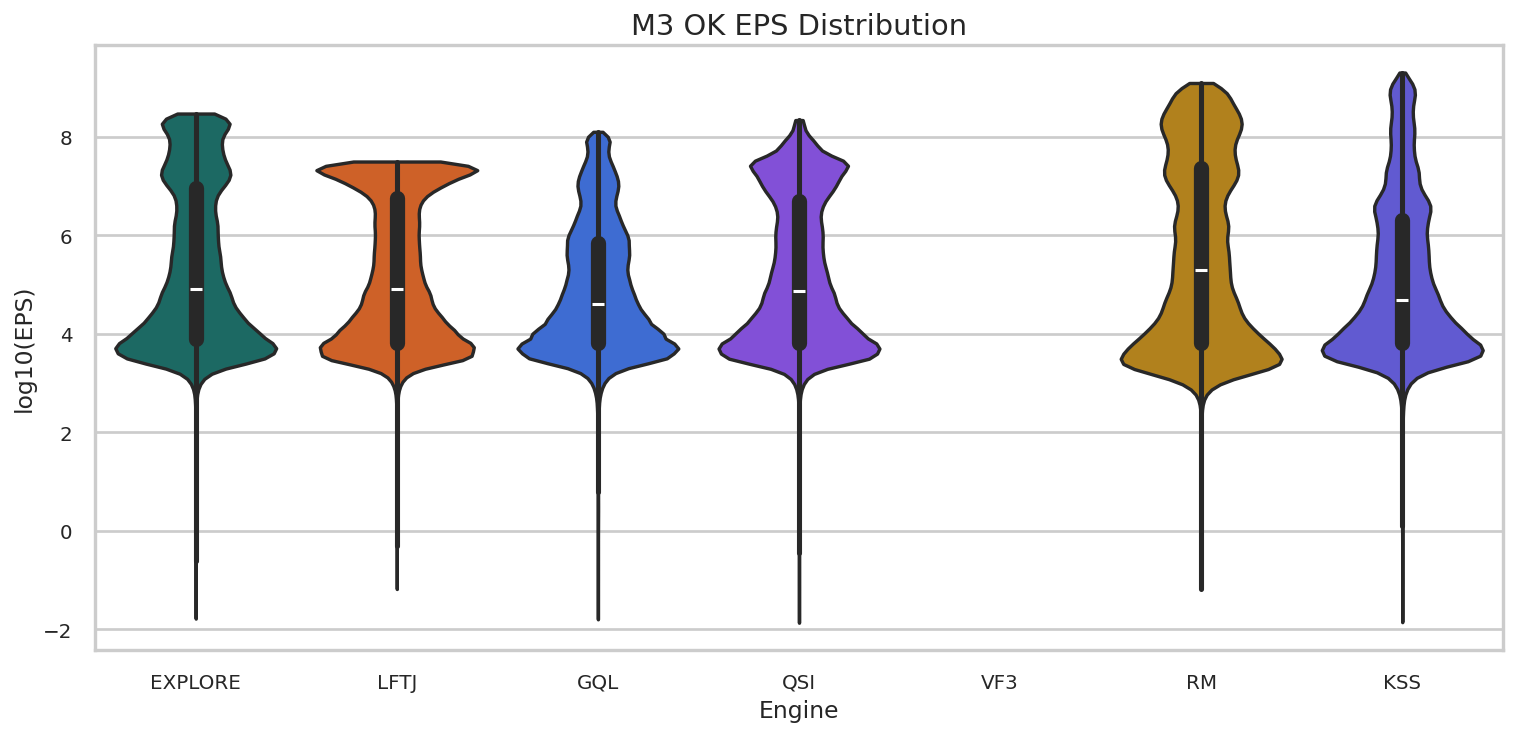

In [5]:
plt.figure(figsize=(12, 6))
ax = lib.plot_eps_distribution(m3_eps_ok)
plt.tight_layout()
plt.savefig(FIG_DIR / "eps_part1_distribution.png", bbox_inches="tight")
plt.show()

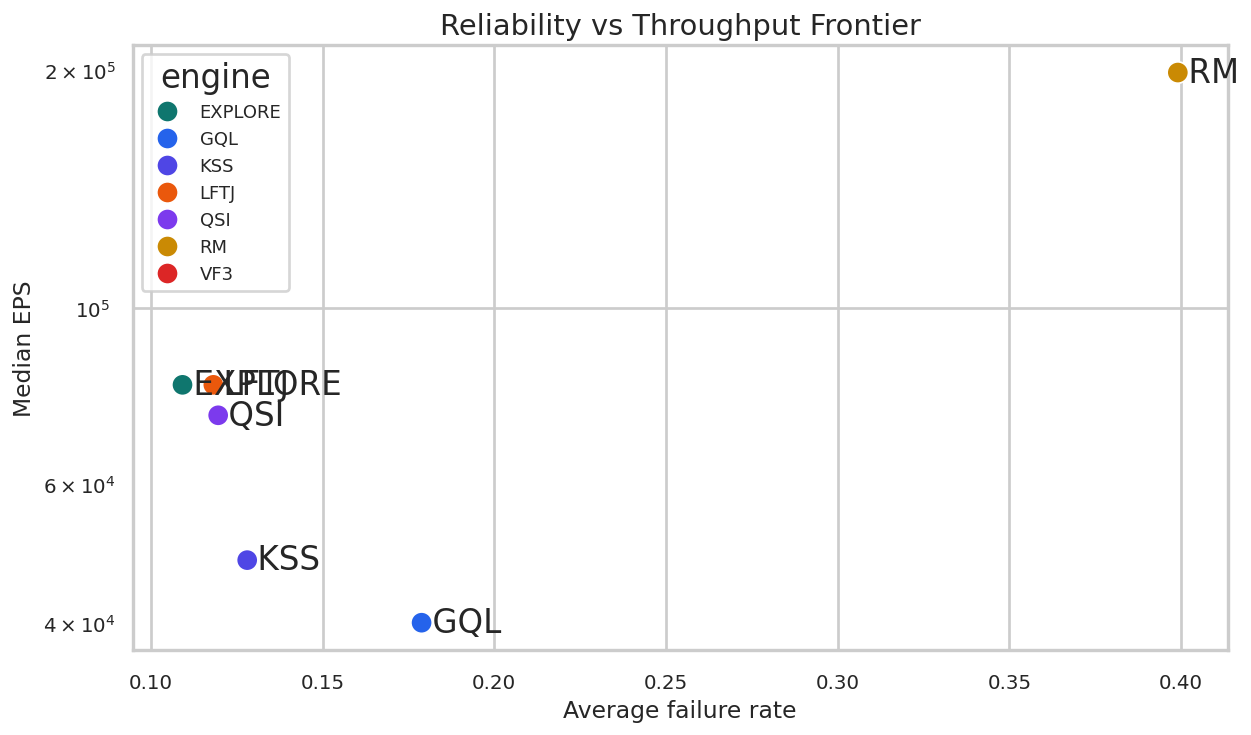

In [6]:
plt.figure(figsize=(10, 6))
ax = lib.plot_reliability_frontier(eps_frontier)
plt.tight_layout()
plt.savefig(FIG_DIR / "eps_part1_reliability_frontier.png", bbox_inches="tight")
plt.show()

## Part 2: Which Engine Wins Under EPS?

Here we repeat the per-sequence winner analysis, but use `EPS` as the score to maximize.

In [7]:
eps_fastest = lib.fastest_engine_by_sequence_metric(m3_eps_ok, metric_col="eps_metric", higher_is_better=True)
eps_gap = lib.metric_gap(m3_eps_ok, metric_col="eps_metric", higher_is_better=True)

eps_fastest.head()

,dataset,engine,win_count,win_share,metric
4,dblp,RM,4857,0.630943,eps_metric
0,dblp,EXPLORE,2527,0.328267,eps_metric
1,dblp,KSS,238,0.030917,eps_metric
2,dblp,LFTJ,64,0.008314,eps_metric
3,dblp,QSI,12,0.001559,eps_metric


<Figure size 1690x780 with 0 Axes>

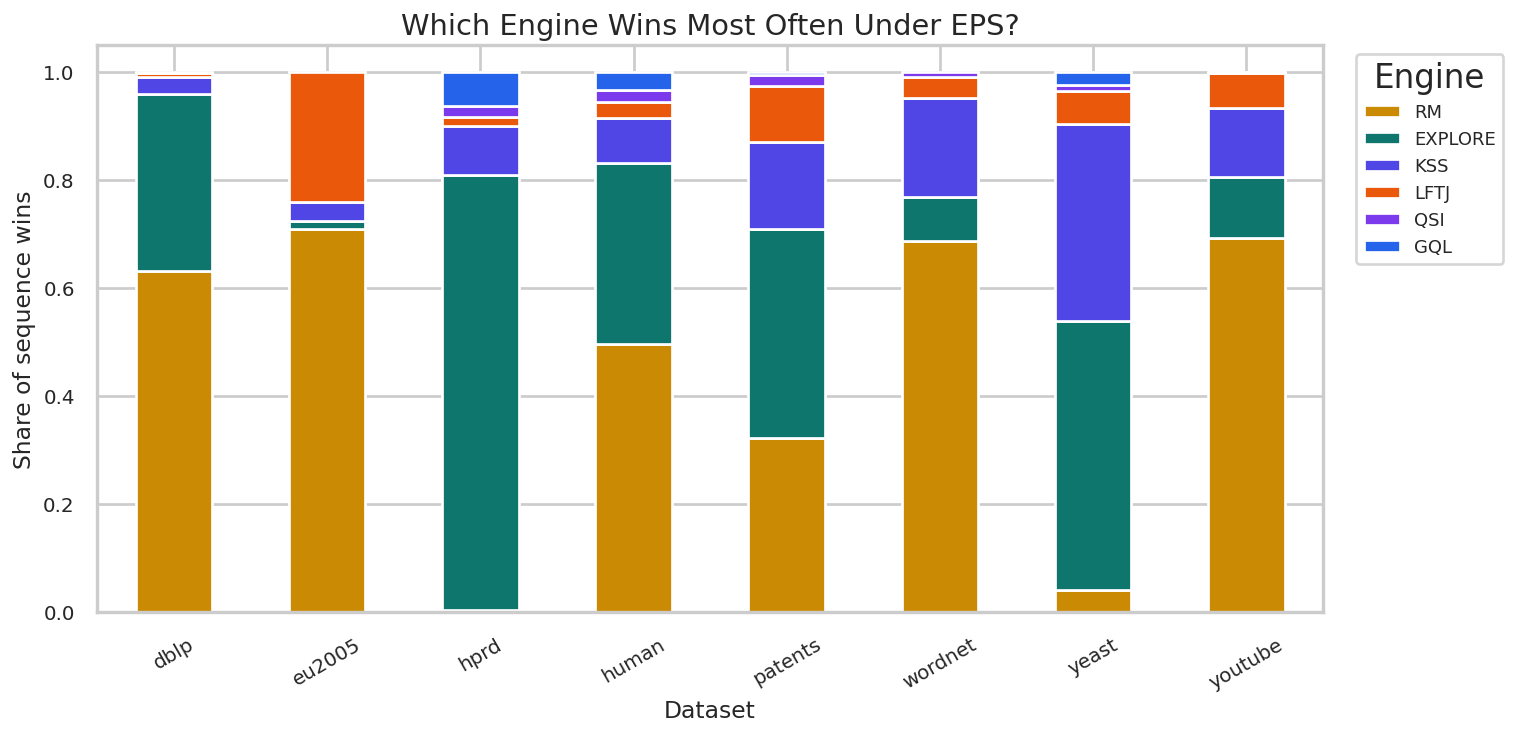

In [8]:
plt.figure(figsize=(13, 6))
ax = lib.plot_metric_winners(eps_fastest, title="Which Engine Wins Most Often Under EPS?", y_label="Share of sequence wins")
plt.tight_layout()
plt.savefig(FIG_DIR / "eps_part2_winners.png", bbox_inches="tight")
plt.show()

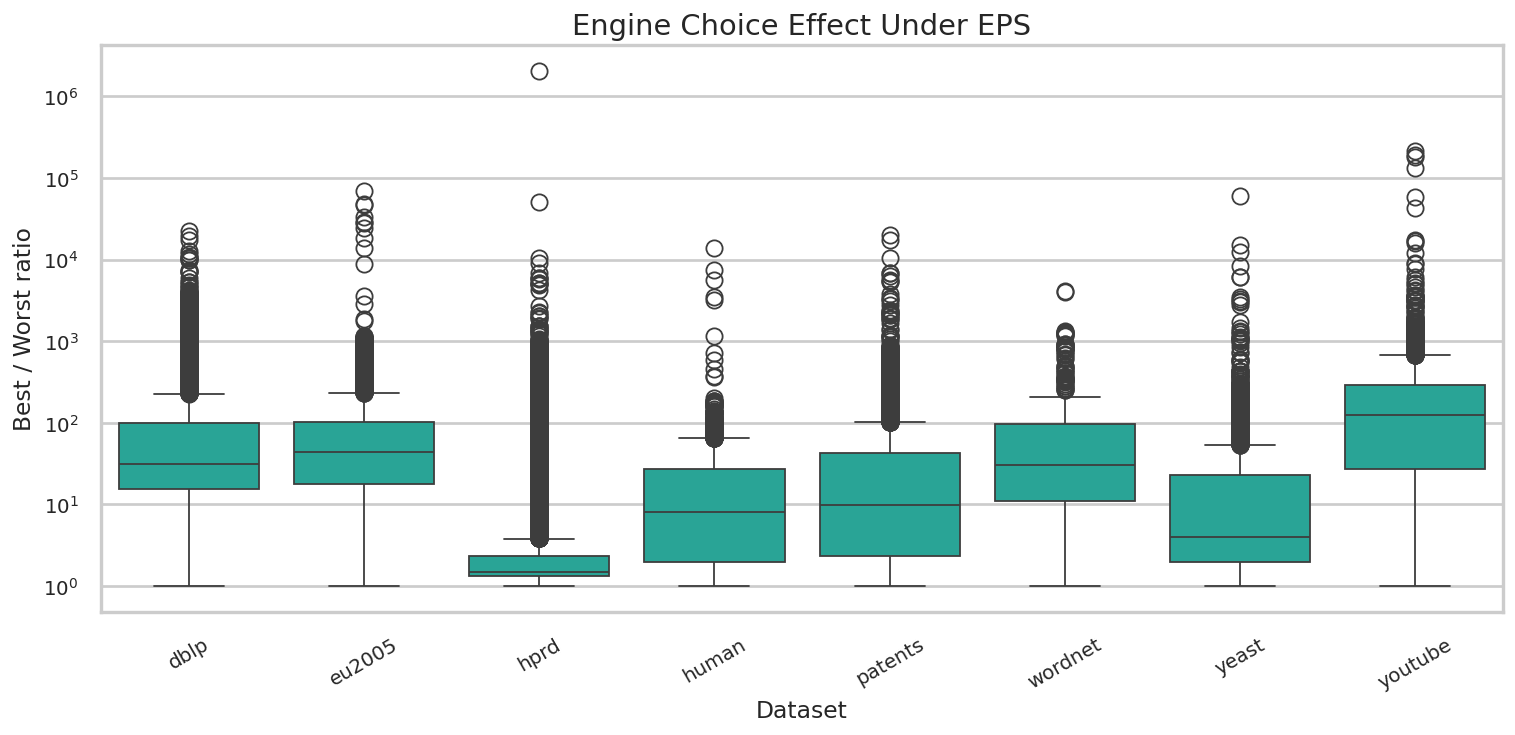

In [9]:
plt.figure(figsize=(12, 6))
ax = lib.plot_metric_gap_distribution(eps_gap, title="Engine Choice Effect Under EPS")
plt.tight_layout()
plt.savefig(FIG_DIR / "eps_part2_gap.png", bbox_inches="tight")
plt.show()

## Part 3: Cross-Engine Ranking Stability Under EPS

We measure how similarly different engines rank the same sequence candidates under throughput.

In [10]:
eps_rank_corr = lib.metric_rank_correlations(m3_eps_ok, metric_col="eps_metric", higher_is_better=True)
eps_universal = lib.metric_universal_best_sequences(m3_eps_ok, metric_col="eps_metric", higher_is_better=True)

eps_rank_corr.head()

,dataset,query_file,engine_a,engine_b,sequence_overlap,spearman_rho,metric
0,dblp,query_dense_10_1.graph,EXPLORE,GQL,25,0.126923,eps_metric
1,dblp,query_dense_10_1.graph,EXPLORE,KSS,25,0.227692,eps_metric
2,dblp,query_dense_10_1.graph,EXPLORE,LFTJ,33,-0.421457,eps_metric
3,dblp,query_dense_10_1.graph,EXPLORE,QSI,33,0.654412,eps_metric
4,dblp,query_dense_10_1.graph,EXPLORE,RM,33,0.781083,eps_metric


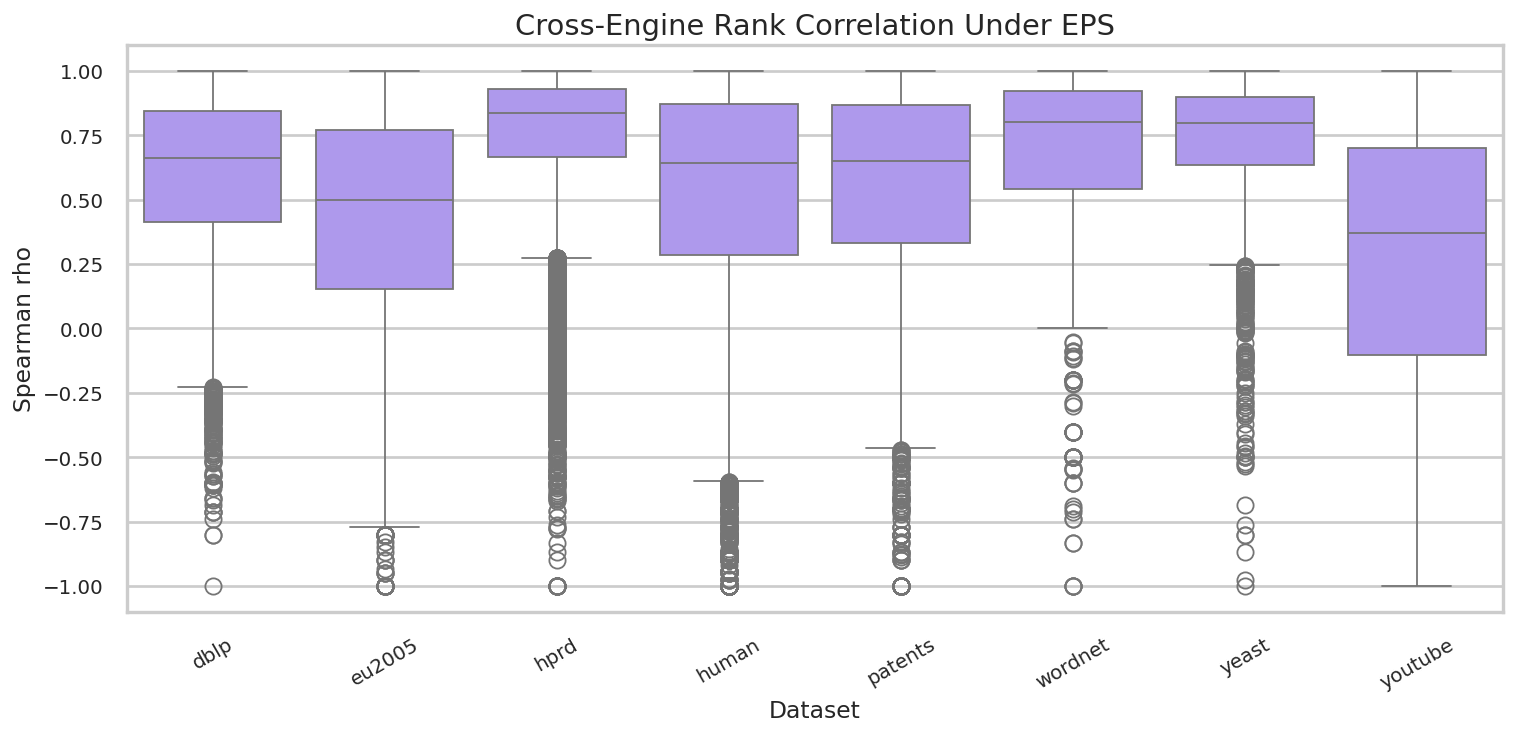

In [11]:
plt.figure(figsize=(12, 6))
ax = lib.plot_rank_correlations(eps_rank_corr)
ax.set_title("Cross-Engine Rank Correlation Under EPS")
plt.tight_layout()
plt.savefig(FIG_DIR / "eps_part3_rank_correlations.png", bbox_inches="tight")
plt.show()

In [12]:
eps_universal_summary = (
    eps_universal.groupby("dataset", as_index=False)
    .agg(
        queries=("query_file", "nunique"),
        universal_best_rate=("universally_good", "mean"),
        median_distinct_best_sequences=("distinct_best_sequences", "median"),
    )
)
eps_universal_summary

,dataset,queries,universal_best_rate,median_distinct_best_sequences
0,dblp,554,0.009025,3.0
1,eu2005,262,0.030534,3.0
2,hprd,4451,0.219501,2.0
3,human,640,0.118750,2.0
4,patents,637,0.061224,3.0
5,wordnet,139,0.280576,2.0
6,yeast,162,0.098765,3.0
7,youtube,440,0.031818,3.0


## Part 4: Sequence Quality Under EPS

Instead of asking how much slower a sequence is, we ask how much throughput is lost by not choosing the best one.

In [13]:
eps_quality = lib.metric_sequence_quality(m3_eps_ok, metric_col="eps_metric", higher_is_better=True)
eps_quality_summary = (
    eps_quality.groupby("dataset", as_index=False)
    .agg(
        median_eps_penalty=("median_penalty_ratio", "median"),
        p90_eps_penalty=("median_penalty_ratio", lambda s: s.quantile(0.9)),
        median_worst_penalty=("worst_penalty_ratio", "median"),
    )
)
eps_quality_summary

,dataset,median_eps_penalty,p90_eps_penalty,median_worst_penalty
0,dblp,1.188062,1.882703,2.947638
1,eu2005,1.112481,1.601021,2.183955
2,hprd,1.200000,1.500000,2.000000
3,human,1.072972,1.750000,1.451613
4,patents,1.126826,2.527468,2.375206
5,wordnet,1.032543,1.388332,1.174694
6,yeast,1.500000,3.000000,5.000000
7,youtube,1.045226,1.710120,1.387755


## Part 5: Enum-Time Winners vs EPS Winners

A key design question for M2 is whether optimizing for shortest runtime and highest throughput leads to the same sequence winner.

In [14]:
agreement = lib.eps_vs_time_winner_agreement(m3_ok, m3_eps_ok)
agreement_summary = (
    agreement.groupby(["dataset", "engine"], observed=True)["same_sequence"]
    .agg(
        winner_agreement_rate="mean",
        query_count="size",
    )
    .reset_index()
)
agreement_summary.sort_values(["dataset", "winner_agreement_rate"], ascending=[True, False])

,dataset,engine,winner_agreement_rate,query_count
1,dblp,GQL,0.723881,536
4,dblp,QSI,0.606884,552
5,dblp,RM,0.523466,554
2,dblp,KSS,0.490942,552
3,dblp,LFTJ,0.479129,551
0,dblp,EXPLORE,0.422383,554
10,eu2005,QSI,0.822785,237
7,eu2005,GQL,0.809045,199
8,eu2005,KSS,0.74502,251
6,eu2005,EXPLORE,0.551587,252


In [15]:
agreement_overall = (
    agreement.groupby("engine", as_index=False)
    .agg(
        winner_agreement_rate=("same_sequence", "mean"),
        query_count=("same_sequence", "size"),
    )
)
agreement_overall

/tmp/ipykernel_363184/3261021290.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreement.groupby("engine", as_index=False)


,engine,winner_agreement_rate,query_count
0,EXPLORE,0.443874,4285
1,GQL,0.461849,6448
2,KSS,0.492554,7185
3,LFTJ,0.43844,5052
4,QSI,0.500397,5036
5,RM,0.663088,7266
6,VF3,<NA>,0


## Part 6: Recommendations for M2 Labels

We summarize what EPS changes, and when M2 should be optimized for throughput instead of only total runtime.

In [16]:
eps_recommendations = pd.DataFrame(
    {
        "question": [
            "Should M2 keep an EPS label?",
            "Does EPS pick the same winner as enum_time?",
            "Which engines look strongest under EPS?",
            "What training target follows from this notebook?",
        ],
        "recommendation": [
            "Yes. EPS should be retained alongside enum_time for paper-aligned evaluation.",
            (
                "Often similar but not identical"
                if agreement["same_sequence"].mean() < 0.95
                else "Nearly identical"
            ),
            ", ".join(
                eps_fastest.groupby("engine", as_index=False)["win_count"].sum().sort_values("win_count", ascending=False).head(3)["engine"]
            ),
            "Use engine-aware ranking, with enum_time and EPS as parallel supervision views.",
        ],
    }
)
eps_recommendations

/tmp/ipykernel_363184/4096186394.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eps_fastest.groupby("engine", as_index=False)["win_count"].sum().sort_values("win_count", ascending=False).head(3)["engine"]


,question,recommendation
0,Should M2 keep an EPS label?,Yes. EPS should be retained alongside enum_tim...
1,Does EPS pick the same winner as enum_time?,Often similar but not identical
2,Which engines look strongest under EPS?,"EXPLORE, RM, KSS"
3,What training target follows from this notebook?,"Use engine-aware ranking, with enum_time and E..."


In [17]:
eps_frames = {
    "eps_frontier": eps_frontier,
    "eps_fastest_engine_summary": eps_fastest,
    "eps_engine_gap": eps_gap,
    "eps_rank_correlations": eps_rank_corr,
    "eps_universal_best_sequences": eps_universal,
    "eps_sequence_quality": eps_quality,
    "eps_winner_agreement": agreement,
    "eps_winner_agreement_summary": agreement_summary,
    "eps_recommendations": eps_recommendations,
}
lib.save_processed_frames(eps_frames)
sorted(p.name for p in PROCESSED_DIR.glob("eps_*.parquet"))

['eps_engine_gap.parquet',
 'eps_fastest_engine_summary.parquet',
 'eps_frontier.parquet',
 'eps_rank_correlations.parquet',
 'eps_recommendations.parquet',
 'eps_sequence_quality.parquet',
 'eps_universal_best_sequences.parquet',
 'eps_winner_agreement.parquet',
 'eps_winner_agreement_summary.parquet']